# Whakaari Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Whakaari dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend.

## 1. Imports and paths

In [8]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import *

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"

In [9]:
X = load_model_frame(WHAKAARI_PATH)
display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,1678,8,2019-10-01 00:00:00+00:00,2019-12-12 23:00:00+00:00,None,effect_tremor_5_15_scaled,-3.461211,-0.034775,4.065084e-16,15.766081,0.661228,1.019055,1678


## 2. Automatic parameter selection, Main configuration and split check

In [10]:
from parameter_extraction import find_parameters

selected_distribution, selected_lag = find_parameters(
    X=X,
    target_series=X[EFFECT],
    max_lags=6,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

pd.DataFrame([{
    "effect": EFFECT,
    "selected_lag": int(selected_lag),
    "selected_distribution": selected_distribution,
    "lag_method": "VAR-AIC",
    "max_lags": 6,
}])

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags
0,effect_tremor_5_15_scaled,4,gaussian,VAR-AIC,6


In [11]:
workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=int(selected_lag),
    max_lags=6,
    min_I1_length=48,
    min_I2_length=48,
    split_method="local_response",
    split_direction="increase",
    split_response_length=48,
    split_search_start=EVENT_TIME - pd.Timedelta(days=7),
    split_search_end=EVENT_TIME + pd.Timedelta(hours=12),
    distribution=selected_distribution,
    parameter_source="automatic",
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,...,split_end_time,split_method,split_direction,split_score,split_response_length,split_search_start,split_search_end,signed_mean_I1,signed_mean_I2,signed_mean_difference
0,effect_tremor_5_15_scaled,1630,2019-12-10 22:00:00+00:00,1630,48,0.086977,2.953604,2.866627,2019-12-09 01:11:00+00:00,1 days 20:49:00,...,2019-12-12 23:00:00+00:00,paper_suffix,absolute_mean,2.866627,48,None,None,-0.086977,2.953604,2.866627


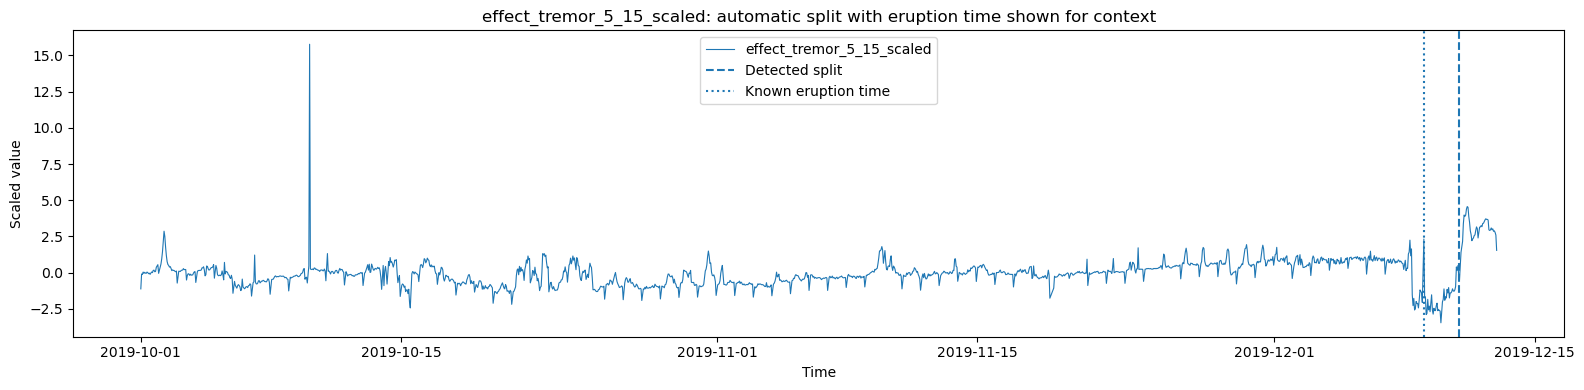

In [12]:
paper_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
    split_method="paper_suffix",
    split_direction="absolute_mean",
    split_response_length=None,
)

display(pd.DataFrame([paper_split]))

plot_effect_with_split(
    X,
    EFFECT,
    paper_split,
    event_time=workflow.event_time,
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,...,split_end_time,split_method,split_direction,split_score,split_response_length,split_search_start,split_search_end,signed_mean_I1,signed_mean_I2,signed_mean_difference
0,effect_tremor_5_15_scaled,1490,2019-12-04 20:00:00+00:00,1490,48,0.074977,0.943832,0.868856,2019-12-09 01:11:00+00:00,-5 days +18:49:00,...,2019-12-06 21:00:00+00:00,local_response,increase,27.214659,48,2019-12-02 01:11:00+00:00,2019-12-09 13:11:00+00:00,-0.074977,0.943832,1.018809


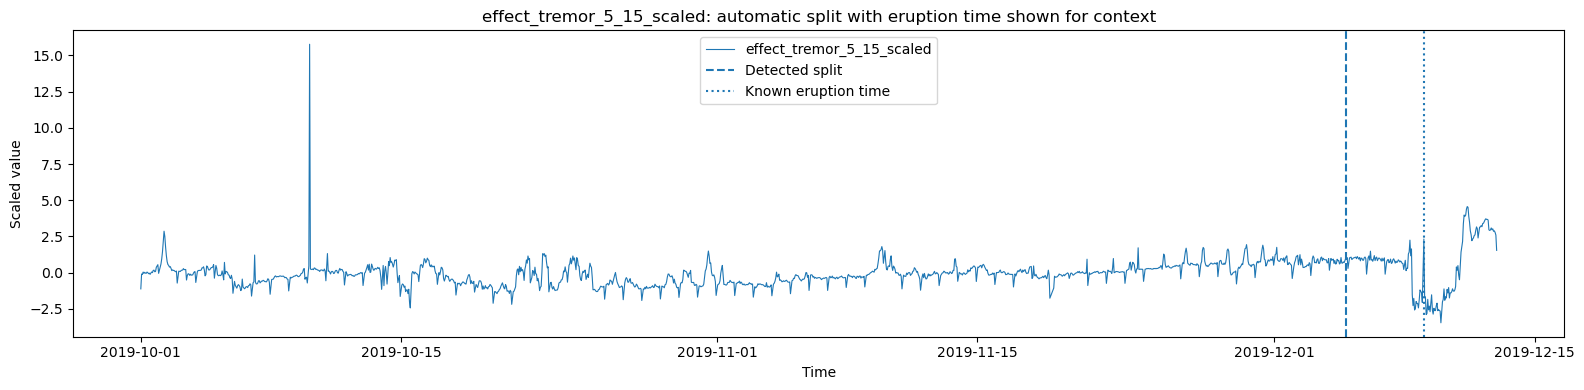

In [13]:
main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
    split_method=workflow.split_method,
    split_direction=workflow.split_direction,
    split_response_length=workflow.split_response_length,
    split_search_start=workflow.split_search_start,
    split_search_end=workflow.split_search_end,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 3. Main run

HMML is the baseline. PCMCI/PCMCI+ are extensions.

In [14]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:14

In [15]:
display(compact_comparison(comparison))
#display(comparison)

,run,backend,configured_lags,configured_distribution,split_timestamp,I1_length,I2_length,B2,trigger_candidates,accepted_triggers,causes,pairs,stop_reason
0,hmml_backend_beta,hmml,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],No trigger candidate leaves a lagged B2 variab...
1,pcmci_ridge,pcmci,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],No lagged non-target B2 variables available to...
2,pcmci_adaptive_lasso,pcmci,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],No lagged non-target B2 variables available to...
3,pcmci_plus_ridge,pcmci_plus,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],No lagged non-target B2 variables available to...
4,pcmci_plus_adaptive_lasso,pcmci_plus,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],No lagged non-target B2 variables available to...


In [16]:
display(compact_diagnostics(diagnostics))
#display(diagnostics)

""


### PCMCI+ run

In [17]:
result_tau0, diag_tau0, row_tau0 = run_one(
    X,
    workflow,
    run_name="pcmci_plus_tau0_ridge",
    backend="pcmci_plus",
    refit_method="ridge",
    parameter_source="automatic_pcmci_plus_tau0_ridge",
    use_contemporaneous_triggers=True,
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)


## 4. Sensitivity check

In [19]:
sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

In [20]:
display(compact_sensitivity(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
0,hmml_backend_beta,hmml,1,gaussian,2019-12-04 20:00:00+00:00,1490,48,[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],None
1,hmml_backend_beta,hmml,2,gaussian,2019-12-04 20:00:00+00:00,1490,48,[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],None
2,hmml_backend_beta,hmml,3,gaussian,2019-12-04 20:00:00+00:00,1490,48,[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],None
3,hmml_backend_beta,hmml,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[SO2_flux_scaled],[SO2_flux_scaled],[],[],[],None
4,hmml_backend_beta,hmml,5,gaussian,2019-12-04 20:00:00+00:00,1490,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...",[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",None
5,hmml_backend_beta,hmml,6,gaussian,2019-12-04 20:00:00+00:00,1490,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled]",[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled), (SO2_flu...",None
6,pcmci_ridge,pcmci,1,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],None
7,pcmci_ridge,pcmci,2,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],None
8,pcmci_ridge,pcmci,3,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],None
9,pcmci_ridge,pcmci,4,gaussian,2019-12-04 20:00:00+00:00,1490,48,[],[],[],[],[],None


In [21]:
display(accepted_sensitivity_rows(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
4,hmml_backend_beta,hmml,5,gaussian,2019-12-04 20:00:00+00:00,1490,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...",[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",None
5,hmml_backend_beta,hmml,6,gaussian,2019-12-04 20:00:00+00:00,1490,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled]",[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled), (SO2_flu...",None
